## BETAGLAS STOCK PRICE PREDICTION

In [2]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

betaglas=pd.read_csv('../stock_data/betaglas.csv') ## so it can be small letter. This is cool.
betaglas=betaglas.drop(columns=['high_price','low_price'])
betaglas.rename(columns={'trade_date':'date'},inplace=True)
betaglas['date']=pd.to_datetime(betaglas['date'])
betaglas['month']=betaglas['date'].dt.month
betaglas['quarter']=betaglas['date'].dt.quarter
betaglas['year']=betaglas['date'].dt.year

betaglas

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,46259,BETAGLAS,2017-02-10,33.07,33.07,50032,2026-04-08T02:43:18.597686+00:00,2,1,2017
1,46351,BETAGLAS,2017-02-13,34.72,34.72,54530,2026-04-08T02:43:22.775561+00:00,2,1,2017
2,46463,BETAGLAS,2017-02-14,34.72,34.72,10300,2026-04-08T02:43:24.286485+00:00,2,1,2017
3,46575,BETAGLAS,2017-02-15,36.45,36.45,70030,2026-04-08T02:43:26.422065+00:00,2,1,2017
4,46687,BETAGLAS,2017-02-16,36.45,36.45,3050,2026-04-08T02:43:28.597754+00:00,2,1,2017
...,...,...,...,...,...,...,...,...,...,...
2230,298031,BETAGLAS,2026-07-13,562.80,562.80,406752,2026-07-13T15:10:02.995074+00:00,7,3,2026
2231,298469,BETAGLAS,2026-07-14,562.80,562.80,34112,2026-07-14T15:10:03.094441+00:00,7,3,2026
2232,298907,BETAGLAS,2026-07-15,562.80,562.80,27879,2026-07-15T15:10:03.078609+00:00,7,3,2026
2233,299345,BETAGLAS,2026-07-16,562.80,562.80,85244,2026-07-16T15:10:03.113936+00:00,7,3,2026


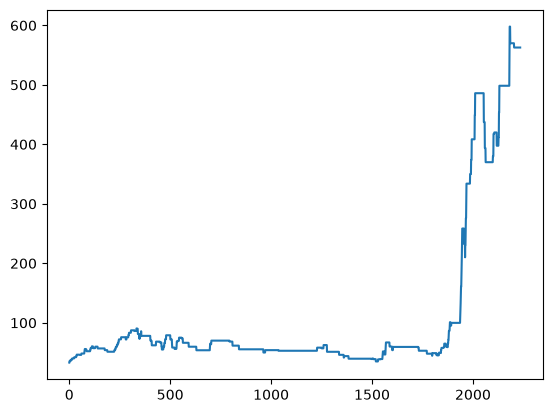

In [3]:
import matplotlib.pyplot as plt

plt.plot(betaglas['close_price'])
plt.show()

In [4]:
betaglas_end_month_df = (
    betaglas
    .sort_values("date")
    .groupby(betaglas["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

betaglas_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,47239,BETAGLAS,2017-02-28,38.27,38.27,40150,2026-04-08T02:44:45.006295+00:00,2,1,2017
1,49355,BETAGLAS,2017-03-31,44.28,44.28,266232,2026-04-08T02:45:42.281198+00:00,3,1,2017
2,51182,BETAGLAS,2017-04-28,46.00,46.00,2314,2026-04-08T02:51:55.619599+00:00,4,2,2017
3,53105,BETAGLAS,2017-05-31,48.29,48.29,6467,2026-04-08T02:52:57.421655+00:00,5,2,2017
4,54945,BETAGLAS,2017-06-30,52.17,52.17,994,2026-04-08T02:53:53.827964+00:00,6,2,2017
...,...,...,...,...,...,...,...,...,...,...
109,35268,BETAGLAS,2026-03-31,498.50,498.50,83681,2026-03-31T15:00:02.085058+00:00,3,1,2026
110,281095,BETAGLAS,2026-04-30,598.00,598.00,790185,2026-04-30T15:00:02.170664+00:00,4,2,2026
111,284161,BETAGLAS,2026-05-29,570.00,570.00,238385,2026-05-29T15:00:02.455558+00:00,5,2,2026
112,294089,BETAGLAS,2026-06-30,562.80,562.80,23271,2026-06-30T15:10:03.08168+00:00,6,2,2026


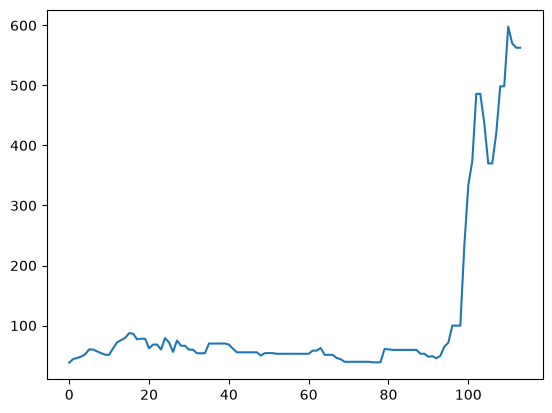

In [5]:
plt.plot(betaglas_end_month_df['close_price'])
plt.show()

In [6]:
betaglas_end_month_df['returns']=betaglas_end_month_df['close_price'].pct_change()*100
betaglas_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,47239,BETAGLAS,2017-02-28,38.27,38.27,40150,2026-04-08T02:44:45.006295+00:00,2,1,2017,NaN
1,49355,BETAGLAS,2017-03-31,44.28,44.28,266232,2026-04-08T02:45:42.281198+00:00,3,1,2017,15.704207
2,51182,BETAGLAS,2017-04-28,46.00,46.00,2314,2026-04-08T02:51:55.619599+00:00,4,2,2017,3.884372
3,53105,BETAGLAS,2017-05-31,48.29,48.29,6467,2026-04-08T02:52:57.421655+00:00,5,2,2017,4.978261
4,54945,BETAGLAS,2017-06-30,52.17,52.17,994,2026-04-08T02:53:53.827964+00:00,6,2,2017,8.034790
...,...,...,...,...,...,...,...,...,...,...,...
109,35268,BETAGLAS,2026-03-31,498.50,498.50,83681,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
110,281095,BETAGLAS,2026-04-30,598.00,598.00,790185,2026-04-30T15:00:02.170664+00:00,4,2,2026,19.959880
111,284161,BETAGLAS,2026-05-29,570.00,570.00,238385,2026-05-29T15:00:02.455558+00:00,5,2,2026,-4.682274
112,294089,BETAGLAS,2026-06-30,562.80,562.80,23271,2026-06-30T15:10:03.08168+00:00,6,2,2026,-1.263158


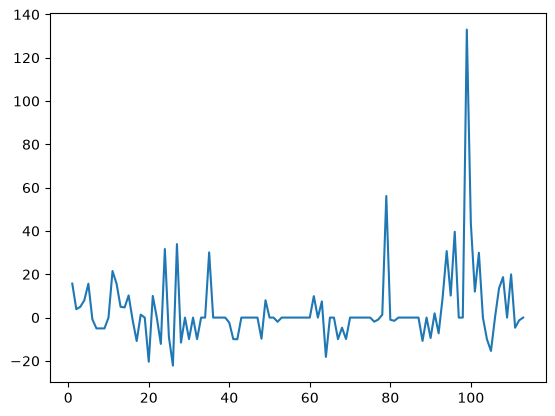

In [7]:
plt.plot(betaglas_end_month_df['returns'])
plt.show()

In [8]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(betaglas_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-4.185815722896996), np.float64(0.0006962903262594015), 2, 110, {'1%': np.float64(-3.4912451337340342), '5%': np.float64(-2.8881954545454547), '10%': np.float64(-2.5809876033057852)}, np.float64(853.9714443722742))
stationary


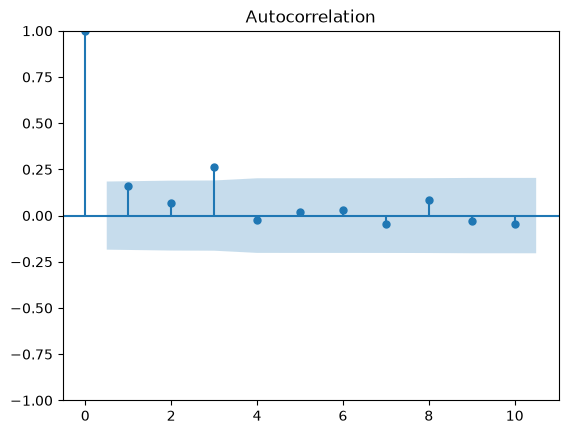

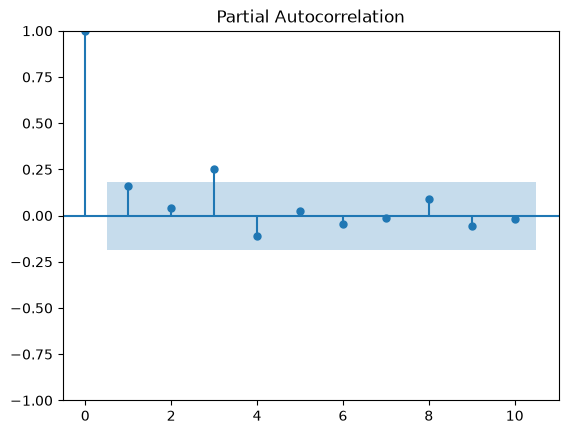

In [9]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(betaglas_end_month_df['returns'].dropna(), lags=10)
plot_pacf(betaglas_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [10]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=betaglas_end_month_df['close_price'][:-10]
test=betaglas_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -36.611011799779774]
[0, 0, 0, 0, 0, 1, -25.270530375452054]
[0, 0, 0, 0, 0, 2, -22.034891234335618]
[0, 0, 0, 0, 1, 0, -17.98001817024499]
[0, 0, 0, 0, 1, 1, -17.441057247152866]
[0, 0, 0, 0, 1, 2, -17.705832569922656]
[0, 0, 0, 0, 2, 0, -14.180422503399459]
[0, 0, 0, 0, 2, 1, -14.185465077389015]
[0, 0, 0, 0, 2, 2, -17.336408924095743]
[0, 0, 0, 1, 0, 0, -20.84652658579895]
[0, 0, 0, 1, 0, 1, -25.791280128017455]
[0, 0, 0, 1, 0, 2, -23.2536541175501]
[0, 0, 0, 1, 1, 0, -17.524243095487975]
[0, 0, 0, 1, 1, 1, -17.896168281048652]
[0, 0, 0, 1, 1, 2, -17.6911908021902]
[0, 0, 0, 1, 2, 0, -14.185799658666449]
[0, 0, 0, 1, 2, 1, -14.180307683333858]
[0, 0, 0, 1, 2, 2, -14.125342889177519]
[0, 0, 0, 2, 0, 0, -21.91620901190765]
[0, 0, 0, 2, 0, 1, -20.7606199712156]
[0, 0, 0, 2, 0, 2, -23.10958877689477]
[0, 0, 0, 2, 1, 0, -17.609597047876058]
[0, 0, 0, 2, 1, 1, -17.640388072613018]
[0, 0, 0, 2, 1, 2, -18.172383036025263]
[0, 0, 0, 2, 2, 0, -14.122099534841059]
[0, 0, 0, 

In [11]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
220,0,2,2,0,2,0,-70.400844
436,1,2,1,0,2,0,-66.379984
652,2,2,0,0,2,0,-59.409341
193,0,2,1,0,2,0,-57.682571
706,2,2,2,0,2,0,-57.287497
...,...,...,...,...,...,...,...
532,2,0,1,2,1,0,0.403997
119,0,1,1,1,1,1,0.410860
111,0,1,1,0,1,2,0.413885
120,0,1,1,1,1,2,0.421976


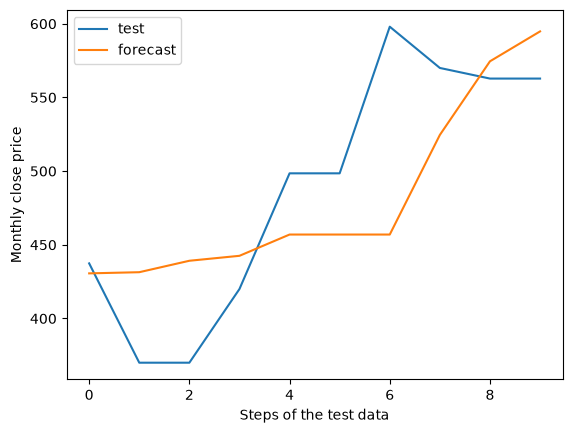

r2_score:  0.45330924839757325
rmse:  59.730506161073365


In [12]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=betaglas_end_month_df['close_price'][:-10]
y_test=betaglas_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,1), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

In [13]:
betaglas_end_month_df.close_price.describe()

count    114.000000
mean     110.539211
std      139.424848
min       38.270000
25%       52.950000
50%       59.400000
75%       71.837500
max      598.000000
Name: close_price, dtype: float64

This is ok.